# <font size=6><b>Lec09. [실습]네이버쇼핑리뷰

In [78]:
import pandas as pd
import numpy as np

import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from konlpy.tag import Mecab
from konlpy.tag import Okt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from collections import Counter
from tqdm import tqdm

from tensorflow.keras.layers import Embedding, Dense, GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# data load

In [3]:
#urllib.request.urlretrieve("https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/naver_shopping.txt", filename="lec09_ratings_total.txt")

('lec09_ratings_total.txt', <http.client.HTTPMessage at 0x19d28798a90>)

In [6]:
df = pd.read_table("./dataset/lec09_ratings_total.txt", names=['ratings', 'reviews'])
df.head(2)

,ratings,reviews
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고


# 전처리 가공

In [7]:
print(df.shape)
df = df.dropna(subset="reviews") #결측
print(df.shape)

(200000, 2)
(200000, 2)


In [8]:
print(df.shape)
df = df.drop_duplicates(subset="reviews") #중복
print(df.shape)

(200000, 2)
(199908, 2)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199908 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ratings  199908 non-null  int64 
 1   reviews  199908 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.6+ MB


## 한글만

In [10]:
# 정규 표현식을 통한 한글 외 문자 제거
df['reviews'] = df['reviews'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
df.head(3)

,ratings,reviews
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서개 더 구매했어요 이가격에 대박입니다 바느질이 조금 엉성...


## 불용어 처리

In [22]:
stop_words_list = stopwords.words('my_korean')
print('불용어 개수 :', len(stop_words_list))
print('불용어 10개 출력 :',stop_words_list[:10])

불용어 개수 : 595
불용어 10개 출력 : ['가', '가까스로', '가령', '각', '각각', '각자', '각종', '갖고말하자면', '같다', '같이']


In [23]:
#mecab = Mecab(dicpath=r"C:/mecab/mecab-ko-dic")
okt = Okt()

tokenized_data = []
for sentence in tqdm(df['reviews']):
    #tokenized_sentence = mecab.morphs(sentence)          # 형태소 토큰화
    tokenized_sentence = okt.morphs(sentence, stem=True)

    #불용어단어, 1글자 제거
    stopwords_removed_sentence = [
        word for word in tokenized_sentence
        if word not in stop_words_list and len(word) > 1
    ]
    tokenized_data.append(stopwords_removed_sentence)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199908/199908 [09:06<00:00, 365.68it/s]


In [15]:
print( len(tokenized_data), len(df) )
tokenized_data[:2]

199908 199908


[['배공', '빠르', '고', '굿'],
 ['택배',
  '가',
  '엉망',
  '이',
  '네',
  '용',
  '저희',
  '집',
  '밑',
  '에',
  '층',
  '에',
  '말',
  '도',
  '없이',
  '놔두',
  '고',
  '가',
  '고']]

In [27]:
temp_list = []
for data in tokenized_data:
    temp_list.append(" ".join(data))
temp_list[:3]

['배공 빠르다',
 '택배 엉망 이네 없이 놔두다',
 '아주 좋다 바지 정말 좋다 구매 하다 가격 대박 이다 바느질 성하다 편하다 가성 최고 예요']

In [28]:
df['reviews2'] = temp_list
df.head(2)

,ratings,reviews,reviews2
0,5,배공빠르고 굿,배공 빠르다
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배 엉망 이네 없이 놔두다


In [29]:
df.to_csv("./dataset/lec09_review.csv", index=False)

## 라벨 긍부정 추가

In [30]:
df['label'] = np.select([df.ratings > 3], [1], default = 0)
df.head(2)

,ratings,reviews,reviews2,label
0,5,배공빠르고 굿,배공 빠르다,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배 엉망 이네 없이 놔두다,0


## 등장빈도 1회 단어버리기

In [41]:
tk = Tokenizer()
tk.fit_on_texts(df['reviews2'])                                #-------------------[1]문장/단어자르기
#문장 자르면 단어사전구축가능
#print(tk.word_index)                                 #-----------사전확인 : 단어 인덱스
#print(tk.word_counts)                                 #-----------사전확인 : 단어 빈도

In [45]:
threshold = 2
total_cnt = len(tk.word_index) # 사전크기(단어의 수)
total_freq = 0                 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_cnt = 0                   # 등장 빈도수가 threshold보다 작은 : 1번 등장한 단어의 개수를 카운트
rare_freq = 0                  # 등장 빈도수가 threshold보다 작은 : 1번 등장한 단어의 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in tk.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :',total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)


단어 집합(vocabulary)의 크기 : 40161
등장 빈도가 1번 이하인 희귀 단어의 수: 20452
단어 집합에서 희귀 단어의 비율: 50.92502676726177
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 1.0884988062278396


In [46]:
40161-20452+1

19710

In [47]:
vocab_sorted = sorted(tk.word_counts.items(), key = lambda x:x[1], reverse = True)
vocab_sorted = vocab_sorted[:19709]
len(vocab_sorted[:19709])
#print(vocab_sorted[:19709])

19709

## 토큰화, 패딩

In [70]:
def below_threshold_len(max_len, nested_list):
  count = 0
  for sentence in nested_list:
    if(len(sentence) <= max_len):
        count = count + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (count / len(nested_list))*100))


In [71]:
max_len = 100
below_threshold_len(max_len, df['reviews2'])

전체 샘플 중 길이가 100 이하인 샘플의 비율: 99.11009064169518


In [84]:
tokenizer = Tokenizer(len(vocab_sorted), oov_token = 'OOV')
tokenizer.fit_on_texts(df['reviews2'])
text = tokenizer.texts_to_sequences(df['reviews2'])
df['reviews3'] = pad_sequences(text, maxlen=100, padding='post').tolist()

df.head(3)

,ratings,reviews,reviews2,label,reviews3
0,5,배공빠르고 굿,배공 빠르다,1,"[10049, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배 엉망 이네 없이 놔두다,0,"[137, 359, 103, 111, 1107, 0, 0, 0, 0, 0, 0, 0..."
2,5,아주좋아요 바지 정말 좋아서개 더 구매했어요 이가격에 대박입니다 바느질이 조금 엉성...,아주 좋다 바지 정말 좋다 구매 하다 가격 대박 이다 바느질 성하다 편하다 가성 최...,1,"[60, 3, 337, 49, 3, 11, 2, 22, 634, 13, 755, 8..."


# eda

## 타겟 불균형 체크

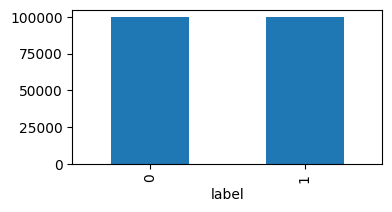

In [32]:
plt.figure(figsize=(4,2))
df['label'].value_counts().plot(kind = 'bar')
plt.show()

## 단어 길이 체크

긍정 리뷰의 평균 길이 : 26.769131491801147
부정 리뷰의 평균 길이 : 34.090550747836524
리뷰의 평균 길이 : 30.42987774376213


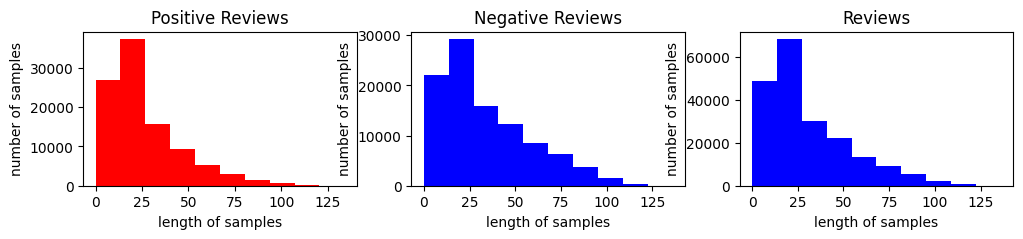

In [39]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(12,2))
text_len = df[df['label']==1]['reviews2'].map(lambda x: len(x))
ax1.hist(text_len, color='red')
ax1.set_title('Positive Reviews')
ax1.set_xlabel('length of samples')
ax1.set_ylabel('number of samples')
print('긍정 리뷰의 평균 길이 :', np.mean(text_len))

text_len = df[df['label']==0]['reviews2'].map(lambda x: len(x))
ax2.hist(text_len, color='blue')
ax2.set_title('Negative Reviews')
ax2.set_xlabel('length of samples')
ax2.set_ylabel('number of samples')
print('부정 리뷰의 평균 길이 :', np.mean(text_len))

text_len = df['reviews2'].map(lambda x: len(x))
ax3.hist(text_len, color='blue')
ax3.set_title('Reviews')
ax3.set_xlabel('length of samples')
ax3.set_ylabel('number of samples')
print('리뷰의 평균 길이 :', np.mean(text_len))
plt.show()

## 워드 클라우드

In [55]:
#! pip install wordcloud

In [53]:
negative_words = np.hstack(df[df.label == 0]['reviews2'].values) # 부정단어 20
positive_words = np.hstack(df[df.label == 1]['reviews2'].values) # 긍정단어 20

negative_word_count = Counter(negative_words)
print(negative_word_count.most_common(20))
print("--"*20)
positive_words = Counter(positive_words)
print(positive_words.most_common(20))

[('그냥 그렇다', 69), ('', 58), ('배송 너무 느리다', 42), ('그렇다', 41), ('좋다', 41), ('배송 느리다', 37), ('별로', 33), ('배송 너무 늦다', 30), ('재다', 28), ('효과 없다', 26), ('배송 늦다', 26), ('생각 보다 별로', 25), ('배송 걸리다', 23), ('별로 이다', 19), ('배송 빠르다 좋다', 19), ('사이즈 작다', 18), ('별로 에요', 17), ('배송 빠르다', 16), ('이다', 16), ('배송 빨르다', 15)]
----------------------------------------
[('좋다', 118), ('배송 빠르다 좋다', 50), ('', 39), ('재다', 37), ('맛있다 먹다', 36), ('맛있다', 35), ('좋다 잘쓰다', 29), ('만족하다', 28), ('먹다', 25), ('너무 좋다', 25), ('받다', 23), ('잘쓰다', 21), ('좋다 좋다', 20), ('괜찮다', 19), ('좋아하다', 19), ('좋다 만족하다', 18), ('가성 좋다', 18), ('편하다 좋다', 18), ('재다 배송 빠르다 좋다', 17), ('배송 빠르다 제품 좋다', 16)]


In [56]:
from wordcloud import WordCloud

In [59]:
def MY_CLOUD_CHART(data):
    wc = WordCloud(font_path='C:/Windows/Fonts/malgun.ttf'
                   ,background_color="white", max_font_size=60)
    
    try : 
        if type(data) == str:
            cloud = wc.generate(data)
        else :
            cloud = wc.generate_from_frequencies(dict(data))
        # cloud.to_file('test.jpg')
        plt.figure(figsize=(5, 3))
        plt.axis('off')
        plt.imshow(cloud)
        plt.show()
    except:
        print("파라미터는 str 또는 dict만 지원합니다")

In [60]:
# LIST --> String로 변환
mylist = ['a','b','c']
print( " ".join(mylist) )
# String --> LIST로 변환
mystr = "1,2,3,4,5"
print(mystr.split(","))

a b c
['1', '2', '3', '4', '5']


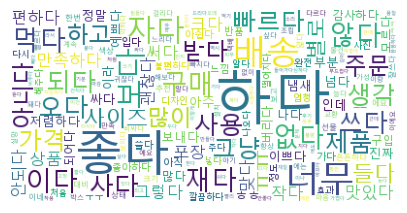

In [62]:
MY_CLOUD_CHART(tk.word_counts)

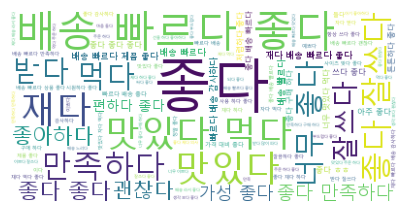

In [63]:
MY_CLOUD_CHART(positive_words)

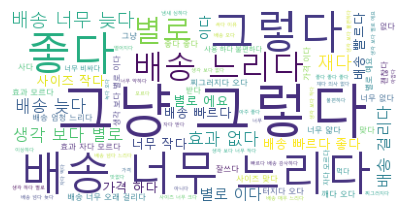

In [68]:
MY_CLOUD_CHART(negative_word_count)

# 긍부정 예측분류모델

In [73]:
df.head(2)

,ratings,reviews,reviews2,label,reviews3
0,5,배공빠르고 굿,배공 빠르다,1,"[10049, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배 엉망 이네 없이 놔두다,0,"[137, 359, 103, 111, 1107, 0, 0, 0, 0, 0, 0, 0..."


In [85]:
y = np.array(df['label'], dtype=np.int32)
X = np.array(df['reviews3'].tolist(), dtype=np.int32)

X80,X20, y80,y20 = train_test_split(X, y, test_size = 0.2, stratify=y,  random_state=8745)
X80.shape,X20.shape, y80.shape,y20.shape 

((159926, 100), (39982, 100), (159926,), (39982,))

In [86]:
embedding_dim = 100
hidden_units = 128

model = Sequential()
model.add(Embedding(len(vocab_sorted), embedding_dim))
model.add(GRU(hidden_units))
model.add(Dense(1, activation='sigmoid'))

MY_STOP = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
MY_CHECK = ModelCheckpoint('best_model.h5', monitor='val_acc', mode='max', save_best_only=True)

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
fit_res= model.fit(X80, y80, epochs=15, callbacks=[MY_STOP, MY_CHECK], batch_size=64, validation_data=(X20,y20))

Epoch 1/15
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - acc: 0.4997 - loss: 0.6935

2499/2499 ━━━━━━━━━━━━━━━━━━━━ 172s 68ms/step - acc: 0.5009 - loss: 0.6933 - val_acc: 0.5000 - val_loss: 0.6932
Epoch 2/15
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 167s 67ms/step - acc: 0.5001 - loss: 0.6932 - val_acc: 0.5000 - val_loss: 0.6932
Epoch 3/15
 762/2499 ━━━━━━━━━━━━━━━━━━━━ 1:46 61ms/step - acc: 0.5009 - loss: 0.6932

# 예측

In [ ]:
best_model = load_model("best_model.h5")

In [ ]:
def MY_PREDICT(new_sentence):
  new_sentence = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]','', new_sentence)
  new_sentence = okt.morphs(new_sentence, stem=True)
  new_sentence = [word for word in new_sentence if not word in stopwords]
    
  encoded = tokenizer.texts_to_sequences([new_sentence])
  pad_new = pad_sequences(encoded, maxlen = max_len)

  score = float(best_model.predict(pad_new))
  if(score > 0.5):
    print("{:.2f}% 확률로 긍정 리뷰입니다.".format(score * 100))
  else:
    print("{:.2f}% 확률로 부정 리뷰입니다.".format((1 - score) * 100))

In [ ]:
MY_PREDICT('진짜 배송도 늦고 개짜증나네요. 뭐 이런 걸 상품이라고 만듬?')

In [ ]:
MY_PREDICT('이 상품 진짜 좋아요... 저는 강추합니다. 대박')